# NBA Playoffs: How do 3-Pointers Affect Win Percentage?

**Dataset:** NBA playoffs team statistics from 2000 to 2021 playoff seasons

In the past 2 decades the NBA has undergone a a stylistic shift towards perimeter-oriented offence. We investigate whether that shift translates into playoff success. Specifically, whether shooting from beyond the arc actually win more playoff games.

**Data Source:** Per-team playoff statistics compiled from NBA.com. The dataet contains 336 records covering 16 playoff teams across 21 seasons (2000-1 to 2020-21)

Pipeline: profiling -> structuring -> enriching -> cleaning -> descriptive analytics -> diagnostic analytics -> predictive analytics.

## Column Dictionary

### Raw columns (from the CSV)

| Column | Type | Description |
|---|---|---|
| `teamstatspk` | int | Unique primary key for each team season record |
| `team` | str | Team name |
| `season` | str | Playoff season |
| `games_played` | str | Total playoff games played |
| `wins` | int | Playoff wins |
| `losses` | int | Playoff losses |
| `win_percentage` | float | Win percentage(wins/games_played), 0-1 scale |
| `minutes` | float | Average minutes per game|
| `points` | float | Average points per game |
| `field_goals_made` | float | Average field goals made per game (FGM) |
| `field_goals_attempted` | float | Average field goals attempted per game (FGA) |
| `field_goal_percentage` | float | FG% = FGM/FGA |
| `three_pointers_made` | float | Average 3-pointers made per game (3PM) |
| `three_pointers_attempted` | float | Average 3-pointers attempted per game (3PA) |
| `three_point_percentage` | float | 3PT% = 3PM/3PA |
| `free_throws_made` | float | Average free throws made per game |
| `free_throw_attempted` | float | Average free throws attempted per game |
| `free_throw_percentage` | float | FT% |

### Derived columns (added during enriching)

| Column | Type | Description |
|---|---|---|
| `three_point_volume` | float | 3PA/FGA - volume of shots taken from 3 |
| `three_point_contribution` | float | ( 3PM x 3)/points - share of points from 3s |
| `season_year` | int | Starting year of season (e.g. 2020 for "2020-21") |
| `playoff_stage` | str | How far the team advanced (R1 Exit, Conf Semis, Conf Finals, Finals, Champion) |



# Data Ingestion

Import libraries and access the csv. The dataset contains per team averaged statistics for every team that participated on the nba playoffs from 2000-01 through 2020-21. Each row represents one teams performance across their entire playoff run for that year.

In [326]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/vikasvittanala/basketball3021/refs/heads/nbaseason/playoffs/data/nba_team_stats_playoffs_00_to_21.csv')
print(f"Dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Year range    : {df['season'].min()} to {df['season'].max()}")
print(f"Unique teams  : {df['team'].nunique()}")
df.head()

Dataset shape : 336 rows x 29 columns
Year range    : 2000-01 to 2020-21
Unique teams  : 35


,teamstatspk,team,games_played,wins,losses,win_percentage,minutes,points,field_goals_made,field_goals_attempted,...,rebounds,assists,turnovers,steals,blocks,blocks_attempted,personal_fouls,personal_fouls_drawn,plus_minus,season
0,0,Milwaukee Bucks,23,16,7,0.696,48.4,110.3,42.1,91.1,...,49.0,22.8,12.7,7.8,4.2,3.8,18.0,20.1,5.1,2020-21
1,1,Phoenix Suns,22,14,8,0.636,48.0,109.0,40.9,85.0,...,42.7,23.2,11.9,6.5,4.2,3.6,19.7,18.5,4.5,2020-21
2,2,Brooklyn Nets,12,7,5,0.583,48.4,112.5,40.7,86.2,...,42.6,22.6,11.6,7.1,4.8,6.2,21.2,18.6,6.3,2020-21
3,3,Philadelphia 76ers,12,7,5,0.583,48.0,116.3,42.5,85.8,...,44.7,24.9,12.8,8.0,6.2,3.8,23.0,23.8,7.5,2020-21
4,4,Atlanta Hawks,18,10,8,0.556,48.0,106.3,38.9,86.8,...,42.4,20.2,12.4,6.7,4.4,4.3,21.2,20.3,-1.5,2020-21


# Data Profiling

We perform both Single-column and Multi-column profiling to assess the quality and usefulness of the data before we structure and enrich.


### Single-column profiling

Examining each columns data type, number of missing values, number of unique values and cardinalities.

In [327]:
numeric_cols = df.select_dtypes(include='number').columns

profile = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique(),
    'Min': df[numeric_cols].min().reindex(df.columns),
    'Max': df[numeric_cols].max().reindex(df.columns),
    'Mean': df[numeric_cols].mean().round(4).reindex(df.columns),
})

print(f"Total records: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print()
profile

Total records: 336
Total columns: 29



,Data Type,Missing Values,Missing %,Unique Values,Min,Max,Mean
teamstatspk,int64,0,0.0,336,0.0,335.000,167.5000
team,str,0,0.0,35,NaN,NaN,NaN
games_played,int64,0,0.0,24,3.0,26.000,10.3214
wins,int64,0,0.0,17,0.0,16.000,5.1607
losses,int64,0,0.0,10,1.0,11.000,5.1607
win_percentage,float64,0,0.0,48,0.0,0.941,0.4018
minutes,float64,0,0.0,23,48.0,53.000,48.3580
points,float64,0,0.0,196,78.0,119.500,97.3738
field_goals_made,float64,0,0.0,120,27.8,44.200,35.5030
field_goals_attempted,float64,0,0.0,163,66.5,96.800,80.8449


### Value Distribution

The Histograms reveal the distribution shape of our most important variables, it helps detect skews and outliers

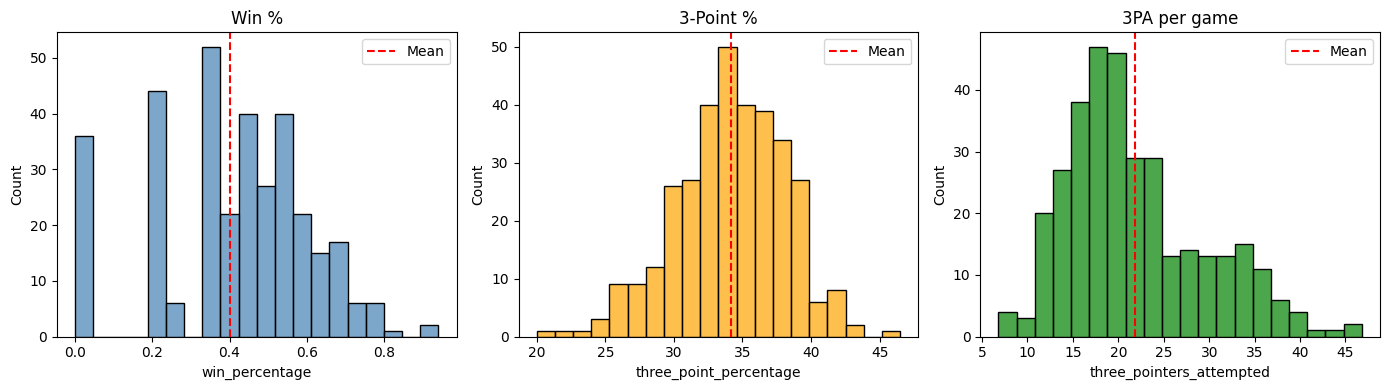

In [348]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue', 'orange', 'green']
for ax, col, title, c in zip(axes,
    ['win_percentage', 'three_point_percentage', 'three_pointers_attempted'],
    ['Win %', '3-Point %', '3PA per game'], colors):
    sns.histplot(df[col], bins=20, color=c, alpha=0.7, ax=ax)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

# The win% centres around 0.5.
# 3PT% has a range from 27-42%, with majority in the middle.
# 3PA is right-skewed, most teams take moderate volume and a few take a lot more.

### Multi-Column Profiling

We look at how columns relate to eachother by checking:

- Uniqueness
- Functional dependencies
- Grouped profile

In [329]:
print(f"teamstatspk is unique key: {df['teamstatspk'].nunique() == len(df)}")

# Check if FGM/FGA actually equals FG% (functional dependency)
fg_match = np.isclose(df['field_goals_made'] / df['field_goals_attempted'], df['field_goal_percentage'], atol=0.15)
print(f"FD (FGM/FGA → FG%): {fg_match.sum()}/{len(df)} rows match")

threept_match = np.isclose(df['three_pointers_made'] / df['three_pointers_attempted'], df['three_point_percentage'], atol=0.15)
print(f"FD (3PM/3PA → 3PT%): {threept_match.sum()}/{len(df)} rows match")
# Using atol=0.15 because data stores per-game averages with rounding

print(f"\nTeams: {df['team'].nunique()}, Seasons: {df['season'].nunique()}")

teamstatspk is unique key: True
FD (FGM/FGA → FG%): 0/336 rows match
FD (3PM/3PA → 3PT%): 0/336 rows match

Teams: 35, Seasons: 21


In [ ]:
def classify_stage(wins):
    if wins < 4:  return 'R1 Exit'
    if wins < 8:  return 'Conf Semis'
    if wins < 12: return 'Conf Finals'
    if wins < 16: return 'Finals'
    return 'Champion'

df['playoff_stage'] = df['wins'].apply(classify_stage)

stages = ['R1 Exit', 'Conf Semis', 'Conf Finals', 'Finals', 'Champion']
group_colums = ['win_percentage', 'three_point_percentage', 'three_pointers_attempted',
              'three_pointers_made', 'field_goal_percentage', 'points']

summary = df.groupby('playoff_stage')[group_colums].mean().round(3).reindex(stages)
summary['n_teams'] = df.groupby('playoff_stage').size().reindex(stages)

print("Mean stats by playoff stage reached:")
summary

Mean stats by playoff stage reached:


,win_percentage,three_point_percentage,three_pointers_attempted,three_pointers_made,field_goal_percentage,points,n_teams
playoff_stage,,,,,,,
R1 Exit,0.244,32.930,21.048,6.996,42.951,95.086,169
Conf Semis,0.497,35.244,22.055,7.833,44.485,99.052,84
Conf Finals,0.571,35.198,23.255,8.207,44.824,99.921,42
Finals,0.654,35.645,21.936,7.932,45.405,99.827,22
Champion,0.724,36.326,23.921,8.695,46.263,101.826,19


Interpretation: Teams that advance to playoffs tend to have a higher 3PT%, higher FG% and score more points per game. Champions teams average noticeably better shooting efficiency than R1 Exit teams, Which hints at 3-point accuracy being linked to playoff success, This observation helps to confirm with correlation analysis later.

# Data Structuring

 Filtering to remove unrelated columns, keeping only columns relevant to our research question. We drop stats like rebounds, assists,steals, blocks and other defensive stats.

 We also normalise shooting percentages to a 0-1 scale so they are consistent with win_percentage. This makes correlations and regression coeffecients more interpretable later.

In [331]:
df2 = df[['teamstatspk', 'team', 'win_percentage', 'minutes', 'points', 'field_goals_made', 'field_goals_attempted', 'field_goal_percentage', 
          'three_pointers_made', 'three_pointers_attempted', 'three_point_percentage', 'free_throws_made', 'free_throw_attempted', 
          'free_throw_percentage','season', 'playoff_stage'
          ]]

df2.head()

for col in ['field_goal_percentage', 'three_point_percentage', 'free_throw_percentage']:
    df2[col] = df2[col] / 100

print(f"Reduced from {df.shape[1]} to {df2.shape[1]} columns")
df2.head()

Reduced from 30 to 16 columns


,teamstatspk,team,win_percentage,minutes,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,season,playoff_stage
0,0,Milwaukee Bucks,0.696,48.4,110.3,42.1,91.1,0.462,11.2,35.0,0.321,14.9,20.8,0.718,2020-21,Champion
1,1,Phoenix Suns,0.636,48.0,109.0,40.9,85.0,0.481,11.2,29.7,0.376,16.0,18.6,0.861,2020-21,Finals
2,2,Brooklyn Nets,0.583,48.4,112.5,40.7,86.2,0.472,13.6,35.6,0.382,17.6,20.3,0.868,2020-21,Conf Semis
3,3,Philadelphia 76ers,0.583,48.0,116.3,42.5,85.8,0.496,11.2,28.4,0.393,20.1,29.3,0.685,2020-21,Conf Semis
4,4,Atlanta Hawks,0.556,48.0,106.3,38.9,86.8,0.449,11.7,34.2,0.343,16.7,20.9,0.798,2020-21,Conf Finals


# Enriching: deriving new attributes 

We add new information to the dataset by deriving new fields with the existing data. We derived two new metrics that capture different aspects of 3 point shooting behaviour:

- three_point_volume
- three_point_contribution

We extract season_year to enable time series analysis later.

In [ ]:

df2['three_point_volume'] = df2['three_pointers_attempted'] / df2['field_goals_attempted']


df2['three_point_contribution'] = (df2['three_pointers_made'] * 3) / df2['points']


df2['season_year'] = df2['season'].str[:4].astype(int)

print("Added: three_point_volume, three_point_contribution, season_year")

df2.head()

Added: three_point_volume, three_point_contribution, season_year


,teamstatspk,team,win_percentage,minutes,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,season,playoff_stage,three_point_volume,three_point_contribution,season_year
0,0,Milwaukee Bucks,0.696,48.4,110.3,42.1,91.1,0.462,11.2,35.0,0.321,14.9,20.8,0.718,2020-21,Champion,0.384193,0.304624,2020
1,1,Phoenix Suns,0.636,48.0,109.0,40.9,85.0,0.481,11.2,29.7,0.376,16.0,18.6,0.861,2020-21,Finals,0.349412,0.308257,2020
2,2,Brooklyn Nets,0.583,48.4,112.5,40.7,86.2,0.472,13.6,35.6,0.382,17.6,20.3,0.868,2020-21,Conf Semis,0.412993,0.362667,2020
3,3,Philadelphia 76ers,0.583,48.0,116.3,42.5,85.8,0.496,11.2,28.4,0.393,20.1,29.3,0.685,2020-21,Conf Semis,0.331002,0.288908,2020
4,4,Atlanta Hawks,0.556,48.0,106.3,38.9,86.8,0.449,11.7,34.2,0.343,16.7,20.9,0.798,2020-21,Conf Finals,0.394009,0.330198,2020


# Data Cleaning

- Completeness - check for missing values
- Uniquness - Check for duplicates
- Accuracy - check if values are within expected ranges
- Consistency - check for outliers that could suggest data errors



In [333]:
print(" Completeness ")
total_null = df2.isnull().sum().sum()
print(f"Total null values: {total_null}")


print(" \n Uniqueness ")
dupes = df2.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df2 = df2.drop_duplicates()
    print(f"Dropped {dupes} duplicates")


print(" \n Accuracy (Value Ranges) ")
for col in ['win_percentage', 'field_goal_percentage', 'three_point_percentage', 'free_throw_percentage']:
    bad = ((df2[col] < 0) | (df2[col] > 1)).sum()
    status = 'OK' if bad == 0 else f'{bad} violations'
    print(f"  {col}: [{df2[col].min():.3f}, {df2[col].max():.3f}] — {status}")

print(" \n Consistency (IQR Outliers) ")
for col in ['three_point_percentage', 'win_percentage']:
    Q1, Q3 = df2[col].quantile(0.25), df2[col].quantile(0.75)
    IQR = Q3 - Q1
    outlie = ((df2[col] < Q1 - 1.5*IQR) | (df2[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {outlie} outliers ")

print("\n Decision: Outliers retained. Extreme playoff performances (e.g. a team sweeping " \
"through the first round with exceptional shooting) are real data, not errors.")

 Completeness 
Total null values: 0
 
 Uniqueness 
Duplicate rows: 0
 
 Accuracy (Value Ranges) 
  win_percentage: [0.000, 0.941] — OK
  field_goal_percentage: [0.380, 0.500] — OK
  three_point_percentage: [0.200, 0.465] — OK
  free_throw_percentage: [0.579, 0.869] — OK
 
 Consistency (IQR Outliers) 
  three_point_percentage: 4 outliers 
  win_percentage: 0 outliers 

 Decision: Outliers retained. Extreme playoff performances (e.g. a team sweeping through the first round with exceptional shooting) are real data, not errors.


In [334]:
df2.describe() # Meta Data

,teamstatspk,win_percentage,minutes,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,three_point_volume,three_point_contribution,season_year
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,167.500000,0.401848,48.358036,97.373810,35.502976,80.844940,0.439167,7.514286,21.796131,0.341616,18.865179,24.949405,0.757080,0.267392,0.227699,2010.000000
std,97.139076,0.205785,0.589860,8.486771,3.117891,5.310325,0.026206,2.934006,7.609955,0.039544,2.992440,3.895815,0.048719,0.083439,0.074372,6.064332
min,0.000000,0.000000,48.000000,78.000000,27.800000,66.500000,0.380000,1.800000,6.800000,0.200000,11.300000,14.500000,0.579000,0.087404,0.058065,2000.000000
25%,83.750000,0.250000,48.000000,90.900000,33.300000,76.800000,0.422000,5.375000,16.575000,0.317750,16.800000,22.000000,0.726000,0.210548,0.175665,2005.000000
50%,167.500000,0.429000,48.000000,96.950000,35.200000,80.800000,0.441500,6.800000,19.800000,0.342000,18.900000,24.600000,0.761000,0.253834,0.213700,2010.000000
75%,251.250000,0.545000,48.500000,103.150000,37.800000,84.800000,0.458000,9.200000,26.125000,0.370000,20.700000,27.725000,0.789000,0.314152,0.274789,2015.000000
max,335.000000,0.941000,53.000000,119.500000,44.200000,96.800000,0.500000,18.000000,46.800000,0.465000,28.200000,36.800000,0.869000,0.545455,0.470752,2020.000000


In [335]:
df2["team"].unique()

<StringArray>
[       'Milwaukee Bucks',           'Phoenix Suns',          'Brooklyn Nets',
     'Philadelphia 76ers',          'Atlanta Hawks',              'Utah Jazz',
            'LA Clippers',       'Dallas Mavericks',         'Denver Nuggets',
     'Los Angeles Lakers', 'Portland Trail Blazers',         'Boston Celtics',
      'Memphis Grizzlies',        'New York Knicks',     'Washington Wizards',
             'Miami Heat',        'Toronto Raptors',  'Oklahoma City Thunder',
        'Houston Rockets',          'Orlando Magic',         'Indiana Pacers',
  'Golden State Warriors',      'San Antonio Spurs',        'Detroit Pistons',
   'New Orleans Pelicans',    'Cleveland Cavaliers', 'Minnesota Timberwolves',
          'Chicago Bulls',      'Charlotte Hornets',   'Los Angeles Clippers',
      'Charlotte Bobcats',    'New Orleans Hornets',        'New Jersey Nets',
       'Sacramento Kings',    'Seattle SuperSonics']
Length: 35, dtype: str

# Descriptive Analytics

Descriptive analytics summarises historical data to answer "what happened?". We apply three methods:

- **Time series trend anlaysis** - How has 3-point usage changed over the playoff period in a season

- **Visualisation (Scatter plots)** - to see if there is a visible relationship between 3PT% and winning

- **Categorical aggregation (Box plots)** - how does Win percent compare to different 3PT% tiers?


### Time Series Trend

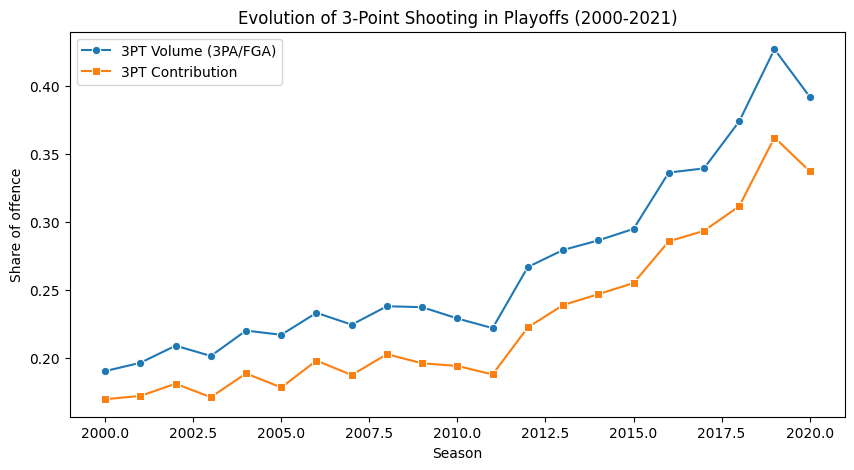

In [336]:
trend = df2.groupby('season_year').agg(
    volume=('three_point_volume', 'mean'),
    contribution=('three_point_contribution', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x='season_year', y='volume', marker='o', label='3PT Volume (3PA/FGA)')
sns.lineplot(data=trend, x='season_year', y='contribution', marker='s', label='3PT Contribution')
plt.xlabel('Season')
plt.ylabel('Share of offence')
plt.title('Evolution of 3-Point Shooting in Playoffs (2000-2021)')
plt.show()


### Visual Relationship: 3PT% vs Win%

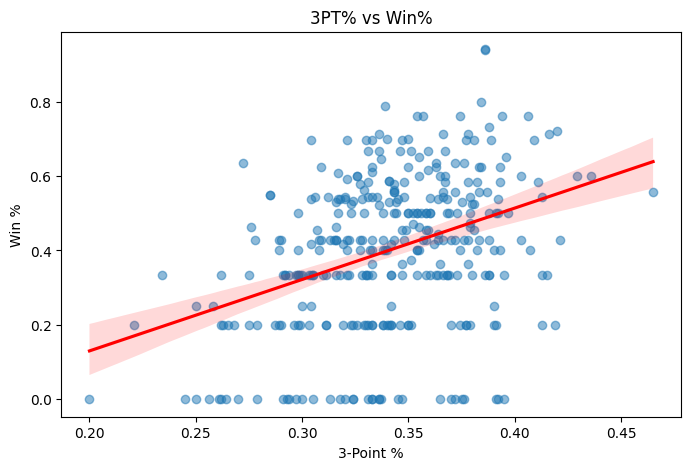

In [337]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df2, x='three_point_percentage', y='win_percentage',
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('3-Point %')
plt.ylabel('Win %')
plt.title('3PT% vs Win%')
plt.show()

### Categorical Comparison

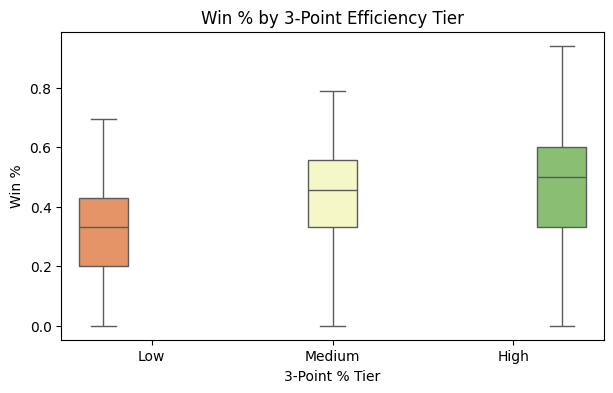

  Low: mean win% = 0.315
  Medium: mean win% = 0.431
  High: mean win% = 0.460


In [338]:
df2['three_pt_tier'] = pd.qcut(df2['three_point_percentage'], 3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(7, 4))
sns.boxplot(data=df2, x='three_pt_tier', y='win_percentage',
            order=['Low', 'Medium', 'High'], hue='three_pt_tier', palette='RdYlGn', legend=False)
plt.title('Win % by 3-Point Efficiency Tier')
plt.xlabel('3-Point % Tier')
plt.ylabel('Win %')
plt.show()

for t in ['Low', 'Medium', 'High']:
    print(f"  {t}: mean win% = {df2[df2['three_pt_tier']==t]['win_percentage'].mean():.3f}")


# Diagnostic Analytics

While descriptive analytics showed us the patterns that exist, diagnostic analytics , measures the strenght and direction of relationships using correlation analysis.

We use Pearson correlation coefficient to quantify how strong each 3-point metric is linearly associated with winning

In [344]:
print(f"{'Metric':<32} {'Pearson':>10} {'Spearman':>10}")
print("-" * 54)
for col in ['three_pointers_made', 'three_pointers_attempted', 'three_point_percentage',
            'three_point_volume', 'three_point_contribution']:
    pr = df2[col].corr(df2['win_percentage'])
    sr = df2[col].corr(df2['win_percentage'], method='spearman')
    print(f"{col:<32} {pr:>+10.4f} {sr:>+10.4f}")

Metric                              Pearson   Spearman
------------------------------------------------------
three_pointers_made                 +0.1687    +0.1782
three_pointers_attempted            +0.0719    +0.0696
three_point_percentage              +0.3690    +0.3433
three_point_volume                  +0.1017    +0.0926
three_point_contribution            +0.1203    +0.1283


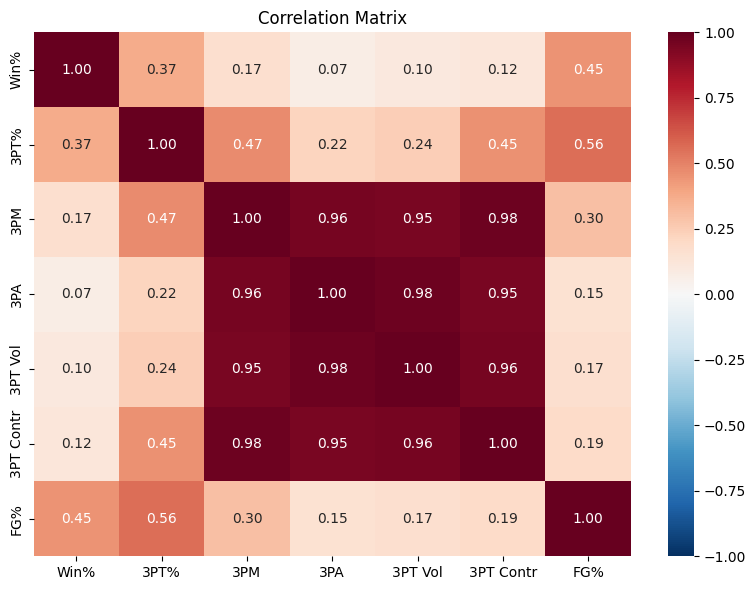

In [345]:
colums = ['win_percentage', 'three_point_percentage', 'three_pointers_made',
        'three_pointers_attempted', 'three_point_volume', 'three_point_contribution',
        'field_goal_percentage']
corr = df2[colums].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=['Win%', '3PT%', '3PM', '3PA', '3PT Vol', '3PT Contr', 'FG%'],
            yticklabels=['Win%', '3PT%', '3PM', '3PA', '3PT Vol', '3PT Contr', 'FG%'])
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Predictive Analytics

Predictive analytics uses historical data to make predictions. We use linear regression since win% is continuous.

We create a line of best fit using np.polyfit, which is equivalent to simple linear regression, and evaluate the model using:

- **R^2** - Proportion of variance n win% explained by 3PT%
- RMSE - Average prediction error

Model: Win% = -0.2542 + 1.9204 x 3PT%
R² = 0.1362, RMSE = 0.1910


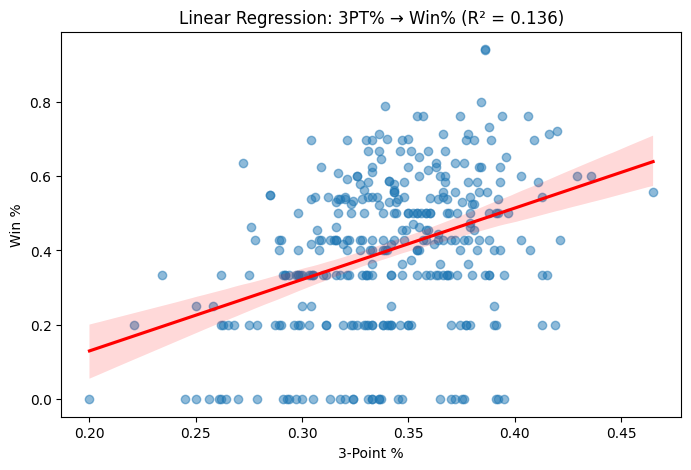


The model shows 13.6% of variance in playoff win%.
The rest is driven by other statistics like defence, rebounding, turnovers, coaching, matchups etc.


In [346]:
x = df2['three_point_percentage'].values
y = df2['win_percentage'].values
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# Evaluate with R-squared and RMSE
r_sq = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)
rmse = np.sqrt(np.mean((y - y_pred)**2))
print(f"Model: Win% = {intercept:.4f} + {slope:.4f} x 3PT%")
print(f"R² = {r_sq:.4f}, RMSE = {rmse:.4f}")

plt.figure(figsize=(8, 5))
sns.regplot(x=x, y=y, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('3-Point %')
plt.ylabel('Win %')
plt.title(f'Linear Regression: 3PT% → Win% (R² = {r_sq:.3f})')
plt.show()

print(f"\nThe model shows {r_sq*100:.1f}% of variance in playoff win%.")
print(f"The rest is driven by other statistics like defence, rebounding, turnovers, coaching, matchups etc.")

In [347]:
df2.to_csv('playoffs_cleaned.csv', index=False)
print(f"Saved {len(df2)} rows to playoffs_cleaned.csv")

Saved 336 rows to playoffs_cleaned.csv


# Conclusion

### Key Findings

- **3- point volume has steadily increased** in the NBA playoffs from 2000 to 2021, showing that there is a league wide shift towards perimeter oriented offence.

- **3PT accuracy correlates more with winning than raw volume**, teams that shoot more efficiently from 3 win more, but simply taking more 3-point shots does not guarantee playoff success

- **Teams in the top 3PT% tier have a clear higher win percentages** than those in the bottom tier for both mean and median

- **Linear regression confirms the relationship is statistically meaningful**, even though 3-point shooting alone is one factore among many that drive playoff success.


